# NDE inference comparison
Let's compare how using different trained NDEs can impact the final posterior

In [1]:
import numpy as np 
from tqdm import tqdm

import emcee
import torch
import optuna

In [2]:
from px2cosmo import fm as FM
from px2cosmo import util as UT

In [3]:
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

## load mock observations

In [4]:
omega_true = np.load("/Users/ch54662/data/px2cosmo/mock/omega_true.npy")
X_obs_z14 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z14.npy")
X_obs_z11 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z11.npy")
X_obs_z9 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z9.npy")

In [5]:
# z=14
_X_obs_z14 = torch.tensor(X_obs_z14[:,:2].astype(np.float32))
_sig_obs_z14 = torch.tensor(X_obs_z14[:,2:].astype(np.float32))
_log1pN_obs_z14 = torch.tensor(np.log1p(X_obs_z14.shape[0]).astype(np.float32))

# z=11
_X_obs_z11 = torch.tensor(X_obs_z11[:,:2].astype(np.float32))
_sig_obs_z11 = torch.tensor(X_obs_z11[:,2:].astype(np.float32))
_log1pN_obs_z11 = torch.tensor(np.log1p(X_obs_z11.shape[0]).astype(np.float32))

# z=9
_X_obs_z9 = torch.tensor(X_obs_z9[:,:2].astype(np.float32))
_sig_obs_z9 = torch.tensor(X_obs_z9[:,2:].astype(np.float32))
_log1pN_obs_z9 = torch.tensor(np.log1p(X_obs_z9.shape[0]).astype(np.float32))

## Test 1: Poisson likelihood

In [9]:
bounds = np.array([[-1.8, -1.5], [-1.8, -1.2], [-0.4, 0.], [-22., -18.], [1e-3, 1e-2]])

def log_prior(omega): 
    alpha, beta, gamma, Muv_s, phi_amp = omega
    if -1.8 < alpha < -1.5 and -1.8 < beta < -1.2 and -0.4 < gamma < 0 and -22 < Muv_s < -18 and 1e-3 < phi_amp < 1e-2: 
        return 0.
    return -np.inf
    
def test_Poisson(zbin, fmodels): 
    _log1pN_obs = {'z14': _log1pN_obs_z14, 
                   'z11': _log1pN_obs_z11, 
                   'z9': _log1pN_obs_z9}[zbin]
    
    ndim, nwalkers = 5, 10
    mcmc_samplers = [] 
    for fmodel in fmodels: 
        p_omegat_log1pN = torch.load(fmodel, weights_only=False, map_location='cpu')
        p_omegat_log1pN._device = 'cpu'

        def _log_p(omega, silent=True): 
            lp = log_prior(omega) # prior 
            if not np.isfinite(lp): return -np.inf
            
            # poisson term of the likelihood
            omega_t = UT.inv_cdf_transform(omega, bounds.T)
            _omega_t = torch.tensor(omega_t.astype(np.float32))
            return p_omegat_log1pN.log_prob(_omega_t, _log1pN_obs, norm_posterior=False).item()
        
        p0 = np.array([
            np.random.uniform(-1.8, -1.5, nwalkers),
            np.random.uniform(-1.8, -1.2, nwalkers),
            np.random.uniform(-0.4,  0.0, nwalkers),
            np.random.uniform(-22.,  -18., nwalkers),
            np.random.uniform(1e-3,  1e-2, nwalkers),
        ]).T
        
        sampler = emcee.EnsembleSampler(nwalkers, ndim, _log_p)
        _ = sampler.run_mcmc(p0, 10000, progress=True)
        mcmc_samplers.append(sampler)
    
    return mcmc_samplers

In [16]:
mcmc_samplers_z14 = test_Poisson('z14',
                                 ['/Users/ch54662/data/px2cosmo/mock/ndes/q_omegat_log1pN_z14/q_omegat_log1pN_z14.28.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/q_omegat_log1pN_z14/q_omegat_log1pN_z14.32.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/q_omegat_log1pN_z14/q_omegat_log1pN_z14.44.pt'])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:36<00:00, 104.00it/s]


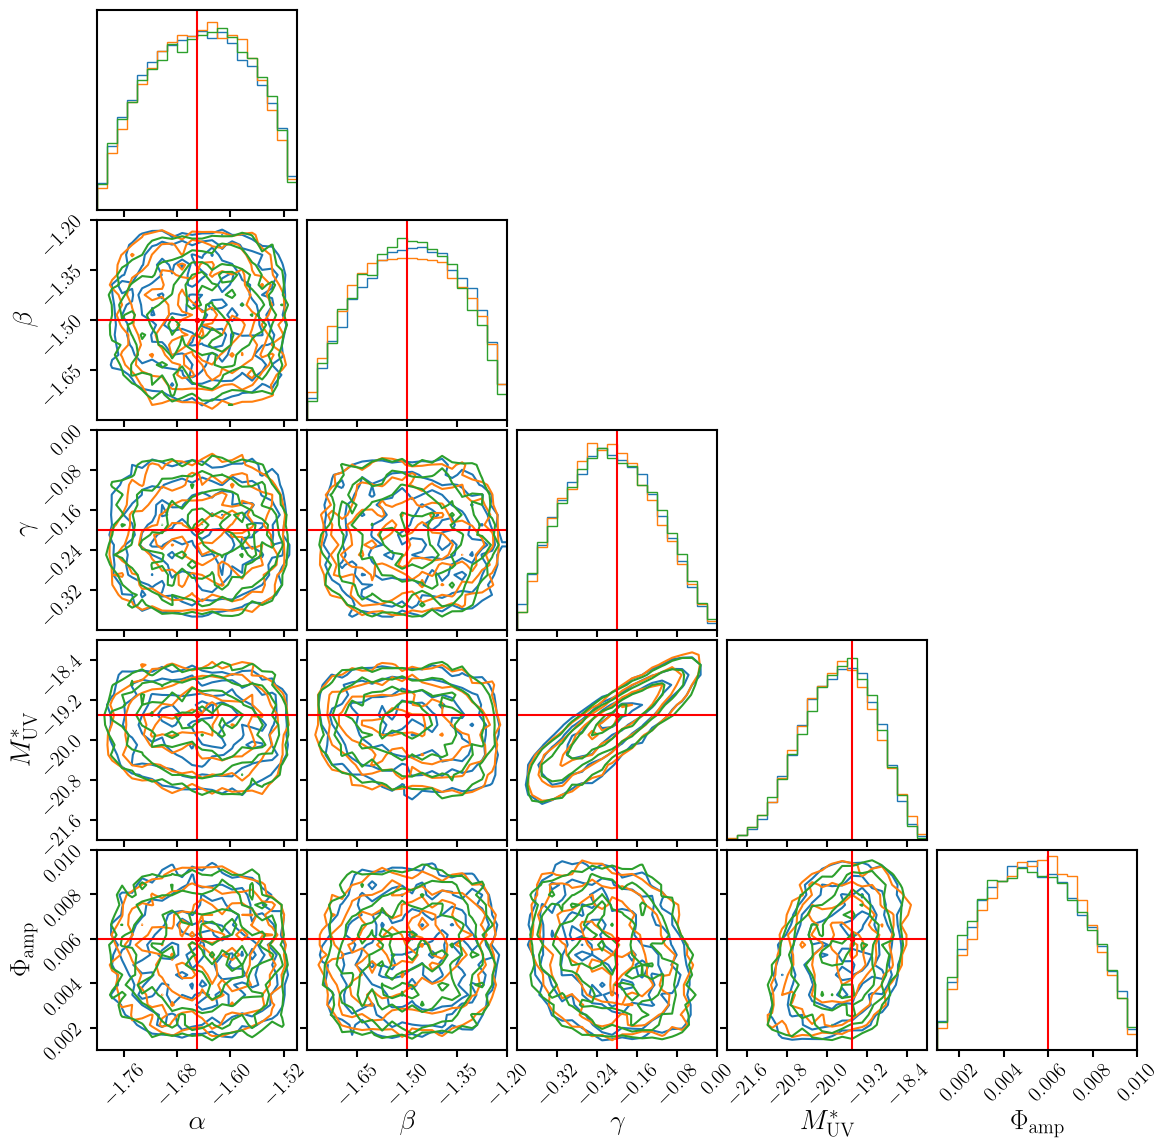

In [17]:
fig = DFM.corner(mcmc_samplers_z14[0].flatchain[5000:,:], color='C0', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(mcmc_samplers_z14[1].flatchain[5000:,:], color='C1', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20},
                 fig=fig)
fig = DFM.corner(mcmc_samplers_z14[2].flatchain[5000:,:], color='C2', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, 
                 fig=fig)

DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

In [12]:
mcmc_samplers_z11 = test_Poisson('z11',
                                 ['/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z11/q_omegat_log1pN_z11.30.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z11/q_omegat_log1pN_z11.32.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z11/q_omegat_log1pN_z11.4.pt'])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:00<00:00, 164.91it/s]


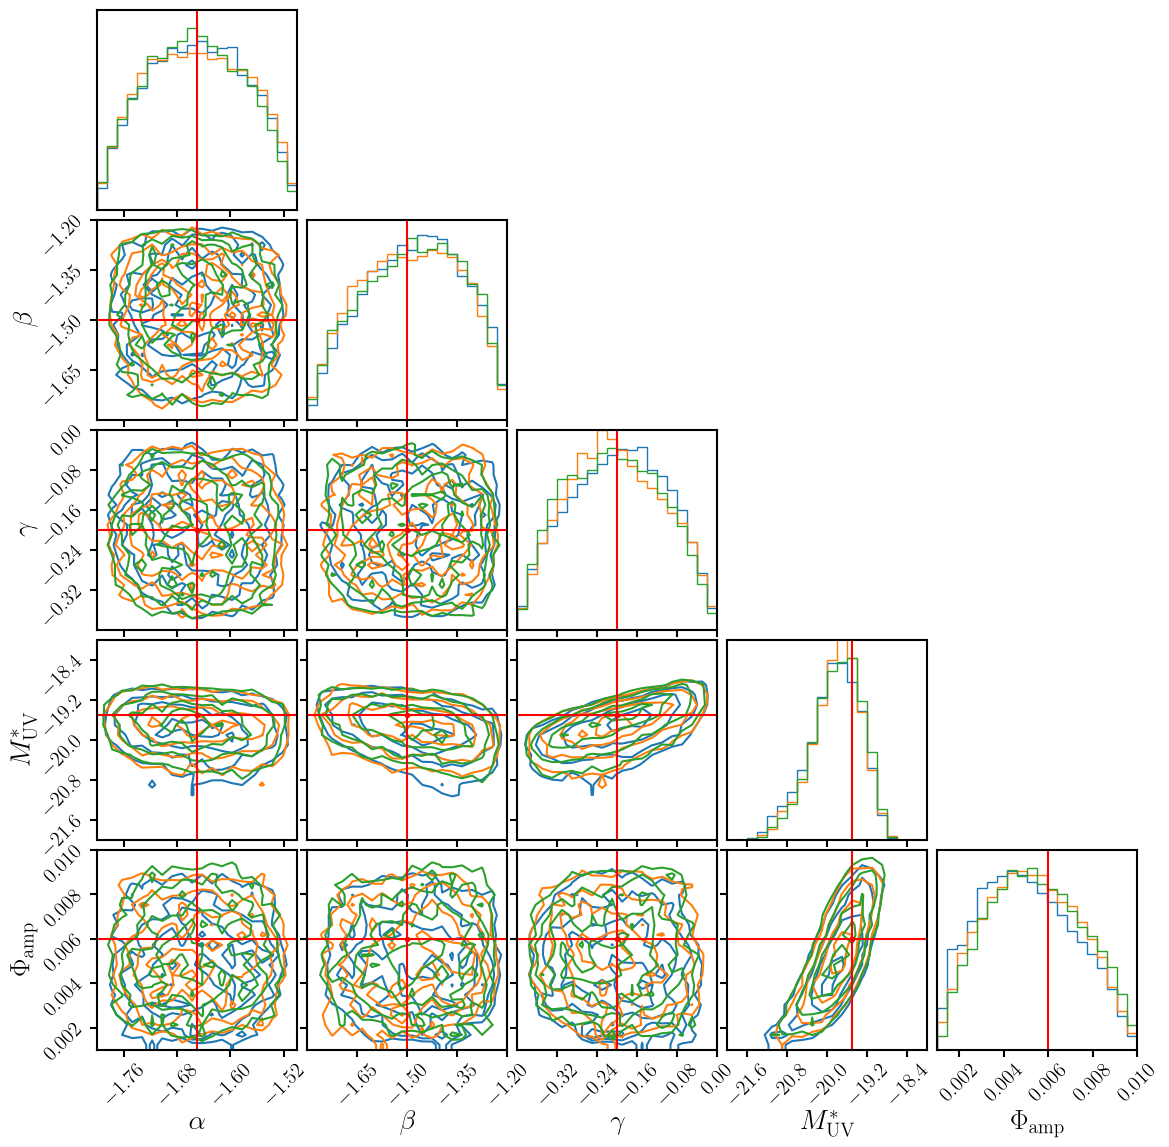

In [13]:
fig = DFM.corner(mcmc_samplers_z11[0].flatchain[5000:,:], color='C0', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(mcmc_samplers_z11[1].flatchain[5000:,:], color='C1', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20},
                 fig=fig)
fig = DFM.corner(mcmc_samplers_z11[2].flatchain[5000:,:], color='C2', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, 
                 fig=fig)

DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

In [14]:
mcmc_samplers_z9 = test_Poisson('z9',
                                 ['/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z9/q_omegat_log1pN_z9.34.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z9/q_omegat_log1pN_z9.68.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z9/q_omegat_log1pN_z9.31.pt'])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:33<00:00, 297.99it/s]


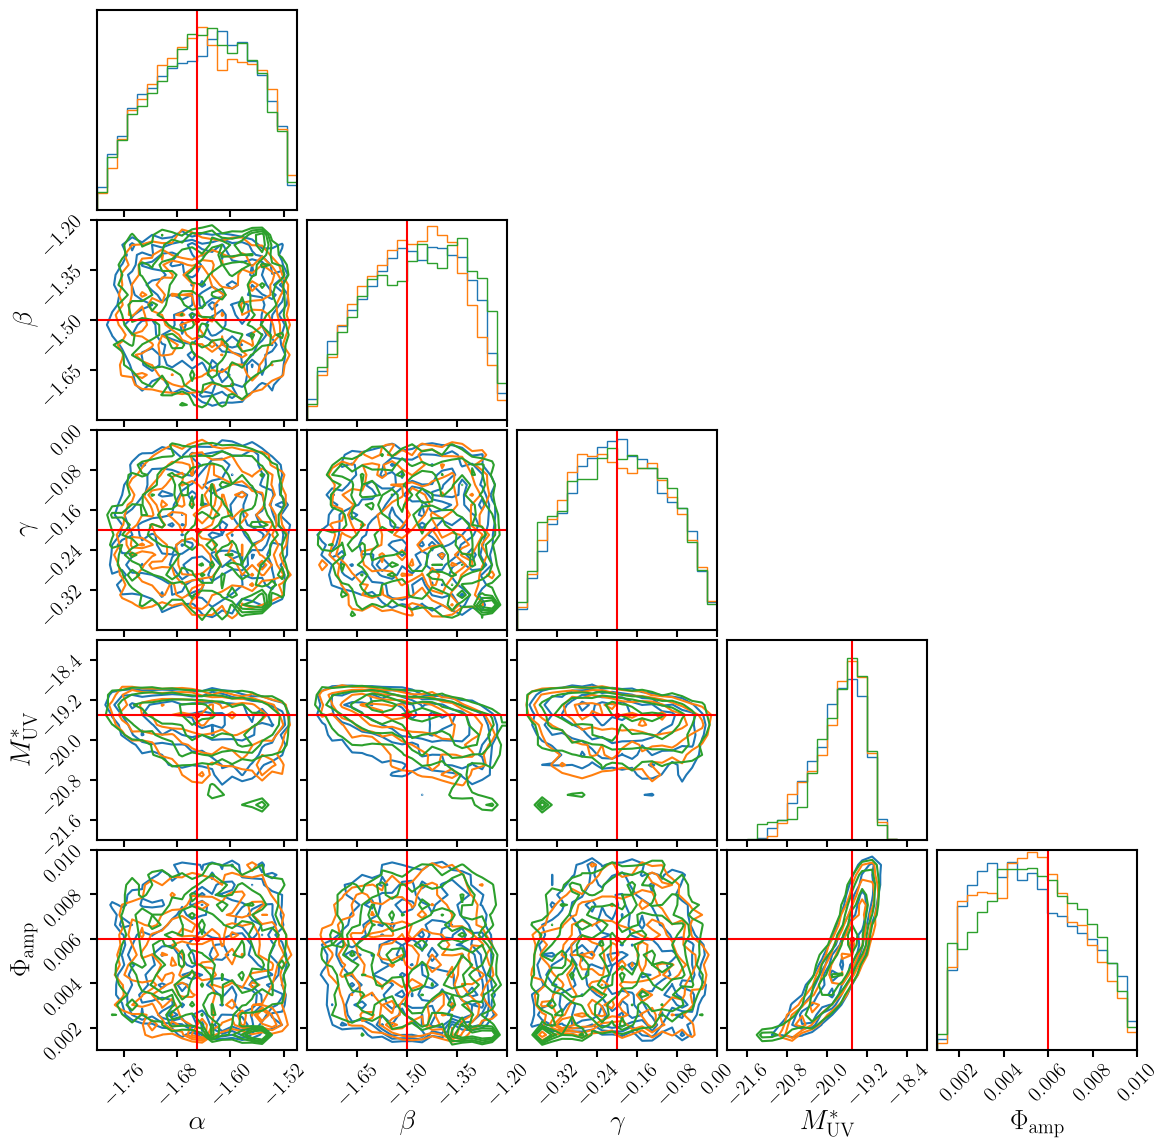

In [15]:
fig = DFM.corner(mcmc_samplers_z9[0].flatchain[5000:,:], color='C0', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(mcmc_samplers_z9[1].flatchain[5000:,:], color='C1', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20},
                 fig=fig)
fig = DFM.corner(mcmc_samplers_z9[2].flatchain[5000:,:], color='C2', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, 
                 fig=fig)

DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

virtually makes no difference. Cool. 

# Test 2: likelihood

In [23]:
def test_likelihood(zbin, fmodels): 
    _X_obs = {'z14': _X_obs_z14, 'z11': _X_obs_z11, 'z9': _X_obs_z9}[zbin]
    _sig_obs = {'z14': _sig_obs_z14, 'z11': _sig_obs_z11, 'z9': _sig_obs_z9}[zbin]
    
    ndim, nwalkers = 5, 10
    mcmc_samplers = [] 
    for fmodel in fmodels: 
        p_X_omegasig_S = torch.load(fmodel, weights_only=False, map_location='cpu')
        p_X_omegasig_S._device = 'cpu'

        def _log_p(omega, silent=True): 
            lp = log_prior(omega) # prior 
            if not np.isfinite(lp): return -np.inf
            
            # log likelihood
            _omega = torch.tensor(omega[:-1].astype(np.float32))
            _omegasig = torch.cat([_omega.expand(_X_obs.shape[0], -1), _sig_obs], dim=1)
            return p_X_omegasig_S.log_prob_batched(_X_obs, _omegasig, norm_posterior=False).sum().item()

        
        p0 = np.array([
            np.random.uniform(-1.8, -1.5, nwalkers),
            np.random.uniform(-1.8, -1.2, nwalkers),
            np.random.uniform(-0.4,  0.0, nwalkers),
            np.random.uniform(-22.,  -18., nwalkers),
            np.random.uniform(1e-3,  1e-2, nwalkers),
        ]).T
        
        sampler = emcee.EnsembleSampler(nwalkers, ndim, _log_p)
        _ = sampler.run_mcmc(p0, 10000, progress=True)
        mcmc_samplers.append(sampler)
    
    return mcmc_samplers

In [24]:
mcmc_samplers_z14 = test_likelihood('z14',
                                 ['/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z14_batch50/q_X_omegasig_z14_batch50.20.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z14_batch50/q_X_omegasig_z14_batch50.36.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z14_batch50/q_X_omegasig_z14_batch50.35.pt'])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [02:09<00:00, 77.49it/s]


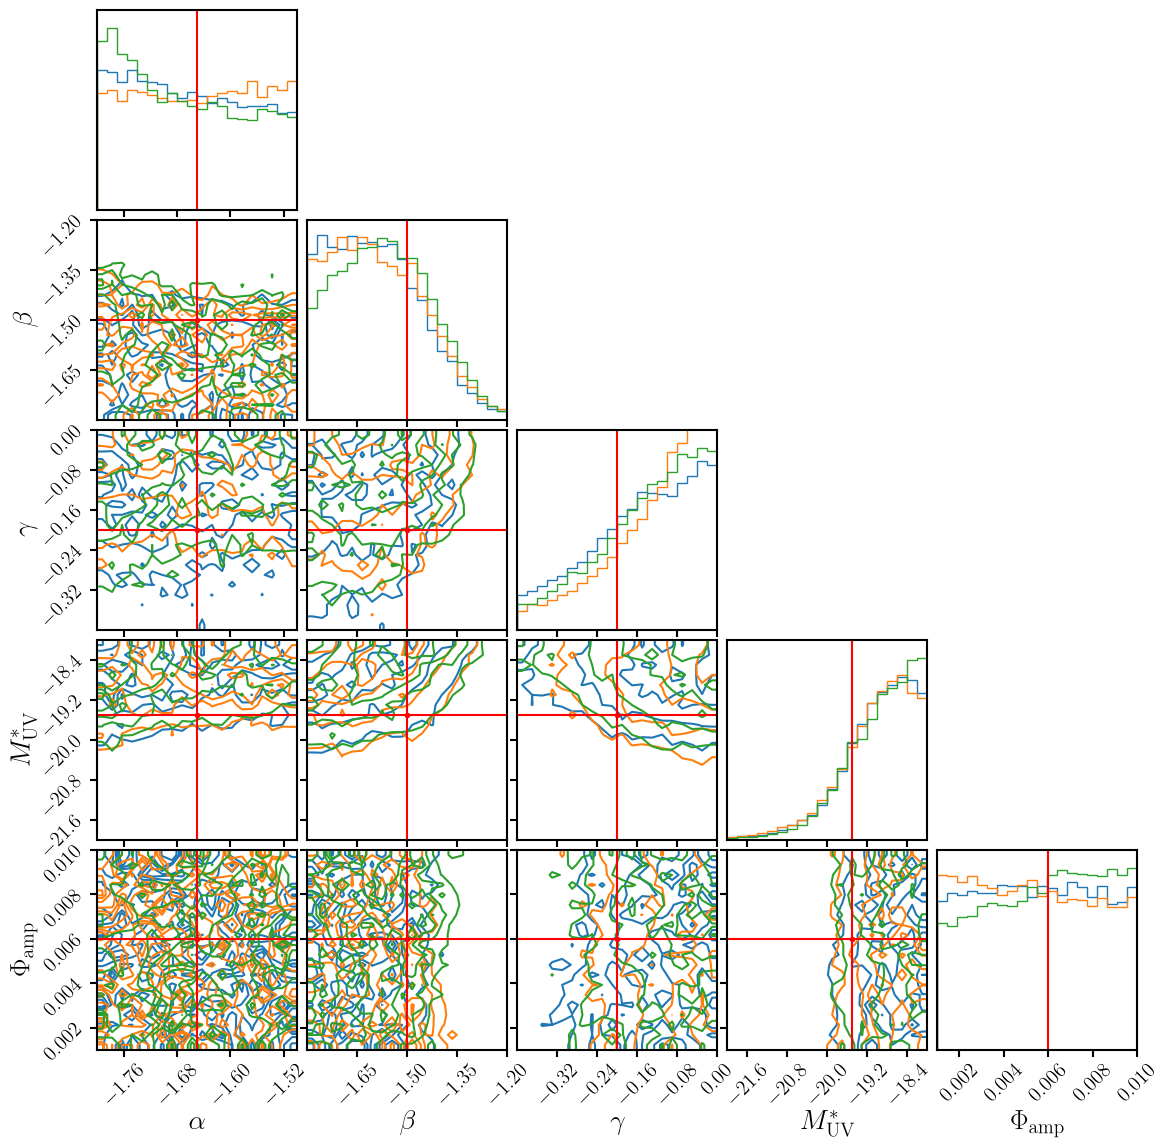

In [25]:
fig = DFM.corner(mcmc_samplers_z14[0].flatchain[5000:,:], color='C0', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(mcmc_samplers_z14[1].flatchain[5000:,:], color='C1', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20},
                 fig=fig)
fig = DFM.corner(mcmc_samplers_z14[2].flatchain[5000:,:], color='C2', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, 
                 fig=fig)

DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

In [26]:
mcmc_samplers_z11 = test_likelihood('z11',
                                 ['/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_X_omegasig_z11/q_X_omegasig_z11.20.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_X_omegasig_z11/q_X_omegasig_z11.17.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_X_omegasig_z11/q_X_omegasig_z11.2.pt'])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:32<00:00, 108.00it/s]


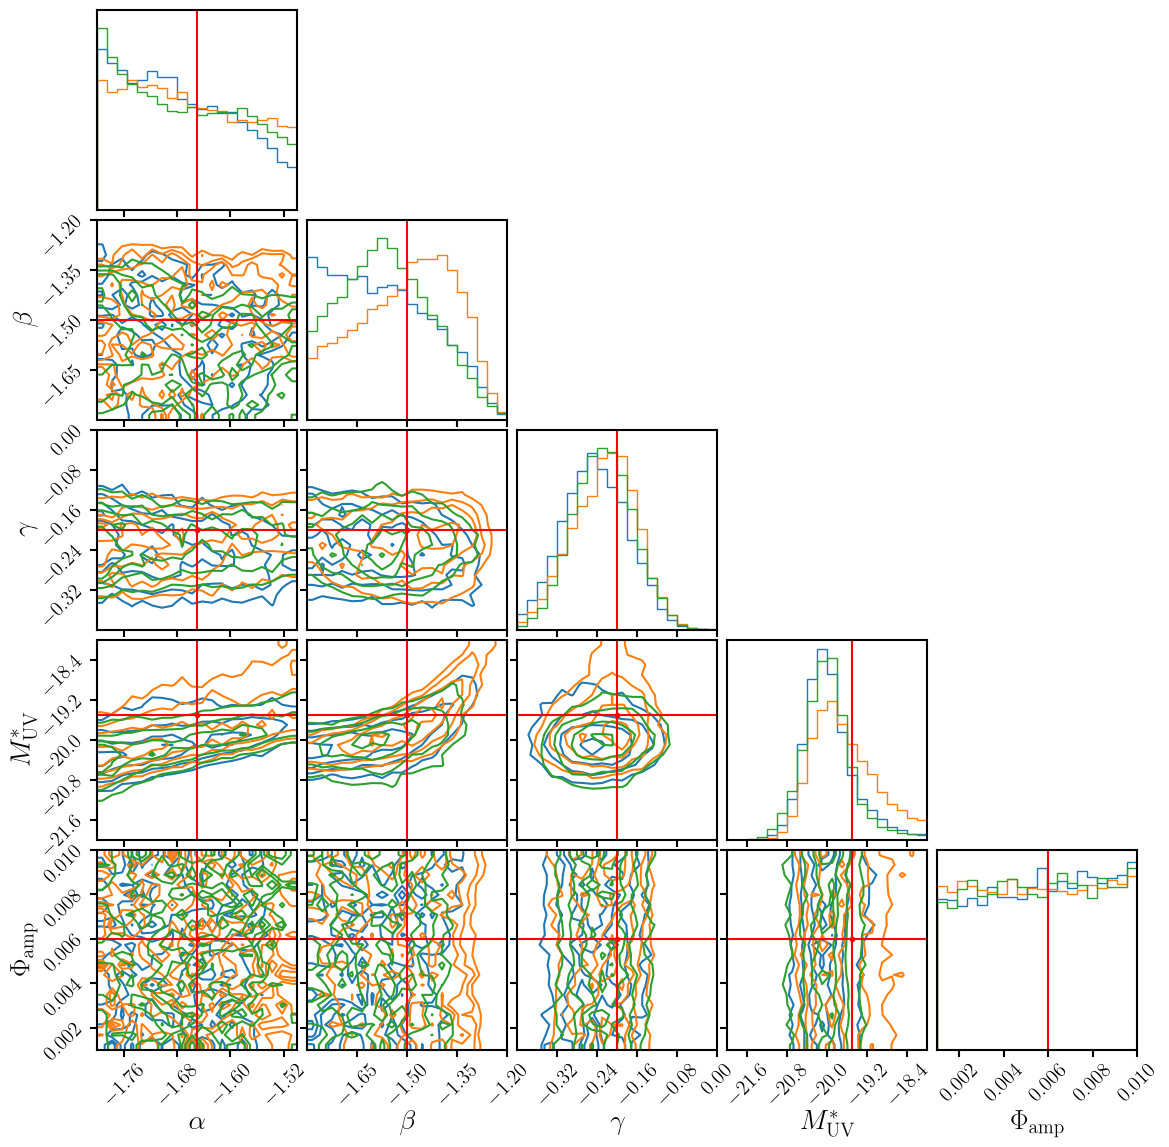

In [27]:
fig = DFM.corner(mcmc_samplers_z11[0].flatchain[5000:,:], color='C0', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(mcmc_samplers_z11[1].flatchain[5000:,:], color='C1', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20},
                 fig=fig)
fig = DFM.corner(mcmc_samplers_z11[2].flatchain[5000:,:], color='C2', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, 
                 fig=fig)

DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

In [28]:
mcmc_samplers_z9 = test_likelihood('z9',
                                 ['/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_down/q_X_omegasig_z9_down.14.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_down/q_X_omegasig_z9_down.8.pt',
                                  '/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_down/q_X_omegasig_z9_down.30.pt'])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:15<00:00, 51.03it/s]


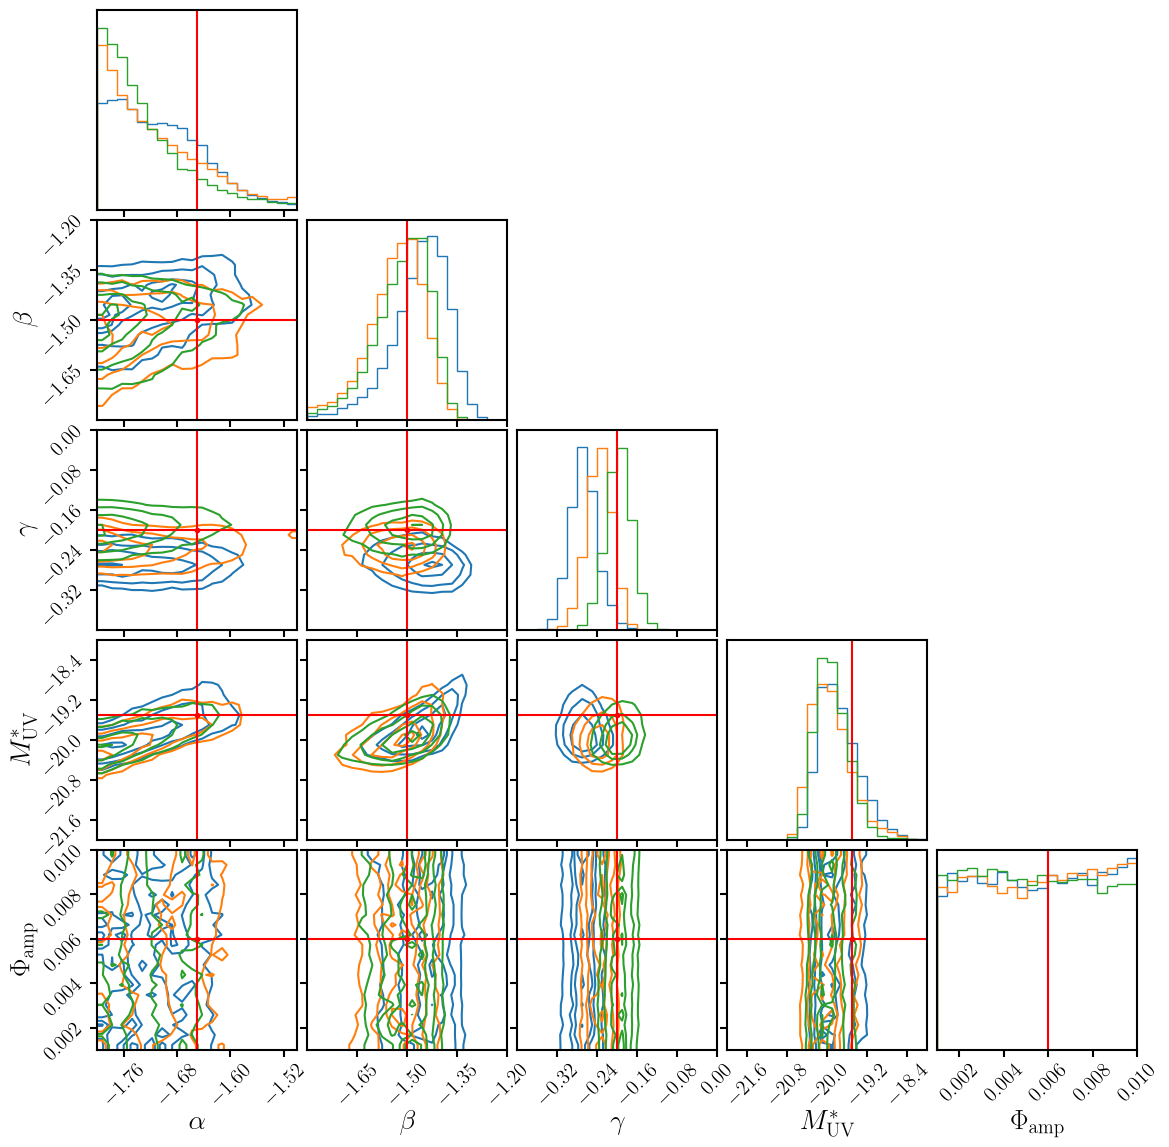

In [29]:
fig = DFM.corner(mcmc_samplers_z9[0].flatchain[5000:,:], color='C0', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(mcmc_samplers_z9[1].flatchain[5000:,:], color='C1', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20},
                 fig=fig)
fig = DFM.corner(mcmc_samplers_z9[2].flatchain[5000:,:], color='C2', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, 
                 fig=fig)

DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

relatively small variational. Cool.